# HYSPLIT Dispersion Modeling

This notebook demonstrates atmospheric dispersion modeling using the `hysplit` package.

**What you'll learn:**
- Running dispersion models with particle emissions
- Configuring emission sources with particle properties
- Visualizing particle dispersion patterns
- Simulating continuous emissions

## Setup

In [1]:
import sys
from pathlib import Path
from datetime import datetime, timedelta

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import hysplit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"hysplit version: {hysplit.__version__}")

met_dir = Path("./met")
out_dir = Path("./out")
met_dir.mkdir(exist_ok=True)
out_dir.mkdir(exist_ok=True)

hysplit version: 0.1.0


## 1. Running a Dispersion Model

The dispersion model simulates how particles are transported and dispersed from an emission source. We define:
- **Source location**: Where particles are released
- **Particle properties**: Diameter, density, and shape factor
- **Emission parameters**: Rate and duration of release

This example matches the R splitr package API:

In [2]:
# Define the start time for our simulation
start_time = datetime(2015, 7, 1, 0, 0)

# Create the dispersion model using method chaining (like R's %>%)
dispersion_model = (
    hysplit.create_dispersion_model()
    .add_source(
        name="particle",
        lat=49.0,
        lon=-123.0,
        height=50,
        rate=5,                    # Emission rate (mass/hour)
        pdiam=15,                  # Particle diameter (micrometers)
        density=1.5,               # Particle density (g/cm³)
        shape_factor=0.8,          # Shape factor (1.0 = sphere)
        release_start=start_time,
        release_end=start_time + timedelta(hours=2)
    )
    .add_dispersion_params(
        start_time=start_time,
        end_time=start_time + timedelta(hours=6),
        direction="forward",
        met_type="reanalysis",
        met_dir=str(met_dir),
        exec_dir=str(out_dir)
    )
    .run()
)

# Get the results as a DataFrame
dispersion_df = dispersion_model.get_output()

if dispersion_df is not None and len(dispersion_df) > 0:
    print(f"Dispersion model completed!")
    print(f"Particles tracked: {len(dispersion_df)}")
    print(dispersion_df.head(10))
else:
    print("Note: Dispersion output requires HYSPLIT hycs_std binary.")
    print("Continuing with trajectory-based dispersion demonstration...")

Dispersion model completed!
Particles tracked: 13750
  particle_i        lat         lon      height
0      00001  48.931198 -122.836426    1.007318
1      00002  48.940109 -122.819183  259.040283
2      00003  48.937912 -122.823975  743.082153
3      00004  48.959381 -122.813049  768.476746
4      00005  48.948273 -122.817200  232.422348
5      00006  48.964600 -122.829666  407.132507
6      00007  48.958160 -122.797821  194.363297
7      00008  48.961395 -122.820572   55.505337
8      00009  48.966949 -122.851379   31.733513
9      00010  48.940659 -122.833740  465.394562


In [10]:
dispersion_df.shape

(13750, 4)

## 2. Dispersion via Trajectory Ensemble

An alternative approach to understanding dispersion is to run multiple trajectories at different heights. This simulates how particles released at different altitudes spread through the atmosphere.

In [3]:
# Source location (Vancouver, Canada)
source_lat = 49.0
source_lon = -123.0

# Run trajectories at multiple heights to show vertical dispersion
heights = [10, 50, 100, 200, 500]
all_trajectories = []

print("Running trajectory ensemble at multiple heights...")
for height in heights:
    traj = hysplit.hysplit_trajectory(
        lat=source_lat,
        lon=source_lon,
        height=height,
        duration=24,
        days=["2012-03-12"],
        daily_hours=[0],
        direction="forward",
        met_type="reanalysis",
        met_dir=str(met_dir),
        exec_dir=str(out_dir)
    )
    traj['start_height'] = height
    all_trajectories.append(traj)
    print(f"  Height {height}m: {len(traj)} points")

traj_dispersion = pd.concat(all_trajectories, ignore_index=True)
print(f"\nTotal trajectory points: {len(traj_dispersion)}")

Running trajectory ensemble at multiple heights...
  Height 10m: 25 points
  Height 50m: 25 points
  Height 100m: 25 points
  Height 200m: 25 points
  Height 500m: 25 points

Total trajectory points: 125


In [4]:
print("Trajectory Dispersion Data:")
print(f"  Starting heights: {sorted(traj_dispersion['start_height'].unique())} m")
print(f"  Hours simulated: {traj_dispersion['hour_along'].max()}")
print(f"  Lat range: {traj_dispersion['lat'].min():.2f} to {traj_dispersion['lat'].max():.2f}")
print(f"  Lon range: {traj_dispersion['lon'].min():.2f} to {traj_dispersion['lon'].max():.2f}")
traj_dispersion.head(10)

Trajectory Dispersion Data:
  Starting heights: [np.int64(10), np.int64(50), np.int64(100), np.int64(200), np.int64(500)] m
  Hours simulated: 24
  Lat range: 49.00 to 55.94
  Lon range: -128.97 to -116.61


,year,month,day,hour,hour_along,lat,lon,height,pressure,traj_dt,traj_dt_i,run,start_height
0,2012,3,12,0,0,49.000,-123.000,10.0,920.9,2012-03-12 00:00:00,2012-03-12,1,10
1,2012,3,12,1,1,49.146,-122.908,14.1,913.9,2012-03-12 01:00:00,2012-03-12,1,10
2,2012,3,12,2,2,49.298,-122.864,20.7,906.9,2012-03-12 02:00:00,2012-03-12,1,10
3,2012,3,12,3,3,49.458,-122.868,30.3,900.2,2012-03-12 03:00:00,2012-03-12,1,10
4,2012,3,12,4,4,49.631,-122.918,43.3,893.6,2012-03-12 04:00:00,2012-03-12,1,10
5,2012,3,12,5,5,49.816,-123.013,59.5,887.2,2012-03-12 05:00:00,2012-03-12,1,10
6,2012,3,12,6,6,50.014,-123.151,79.0,881.1,2012-03-12 06:00:00,2012-03-12,1,10
7,2012,3,12,7,7,50.231,-123.320,104.4,876.5,2012-03-12 07:00:00,2012-03-12,1,10
8,2012,3,12,8,8,50.479,-123.512,138.6,871.0,2012-03-12 08:00:00,2012-03-12,1,10
9,2012,3,12,9,9,50.764,-123.734,181.2,864.9,2012-03-12 09:00:00,2012-03-12,1,10


## 3. Visualizing Dispersion Patterns

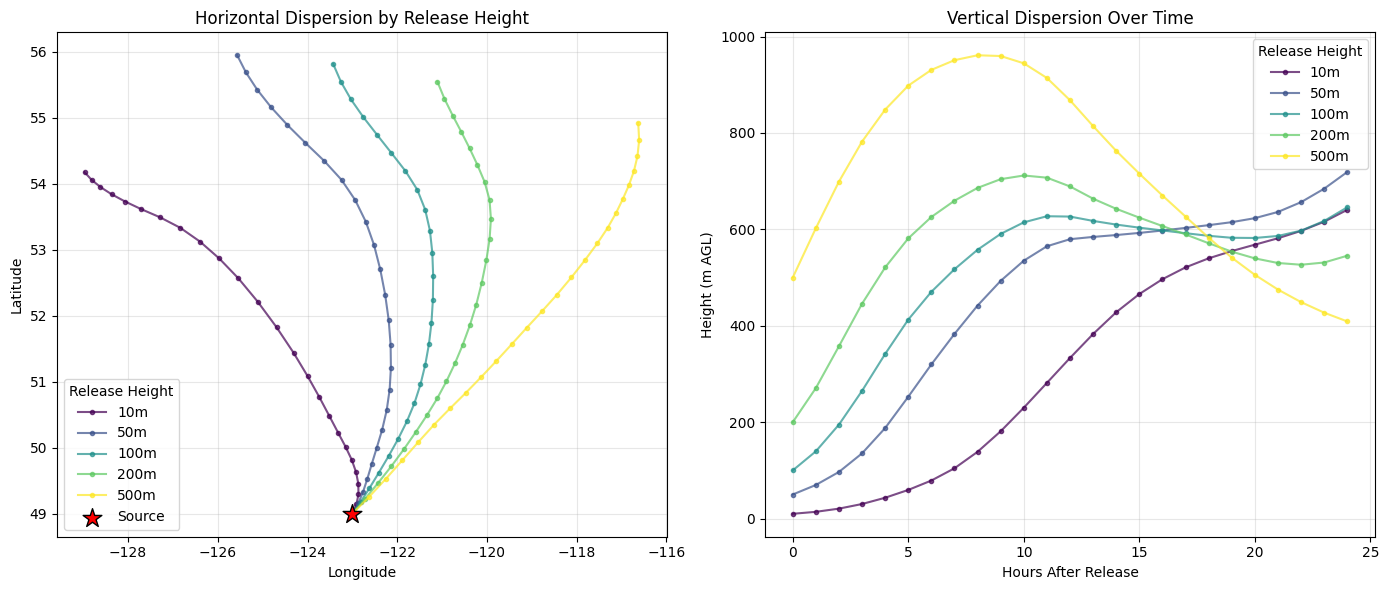

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Horizontal dispersion
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(heights)))

for i, height in enumerate(heights):
    traj_data = traj_dispersion[traj_dispersion['start_height'] == height]
    ax.plot(traj_data['lon'], traj_data['lat'], 'o-', 
            color=colors[i], markersize=3, alpha=0.7, label=f'{height}m')

ax.scatter(source_lon, source_lat, c='red', s=200, marker='*', 
           zorder=10, label='Source', edgecolors='black')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Horizontal Dispersion by Release Height')
ax.legend(title='Release Height')
ax.grid(True, alpha=0.3)

# Plot 2: Vertical dispersion
ax = axes[1]
for i, height in enumerate(heights):
    traj_data = traj_dispersion[traj_dispersion['start_height'] == height]
    ax.plot(traj_data['hour_along'], traj_data['height'], 'o-',
            color=colors[i], markersize=3, alpha=0.7, label=f'{height}m')

ax.set_xlabel('Hours After Release')
ax.set_ylabel('Height (m AGL)')
ax.set_title('Vertical Dispersion Over Time')
ax.legend(title='Release Height')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Time Evolution of Particle Cloud

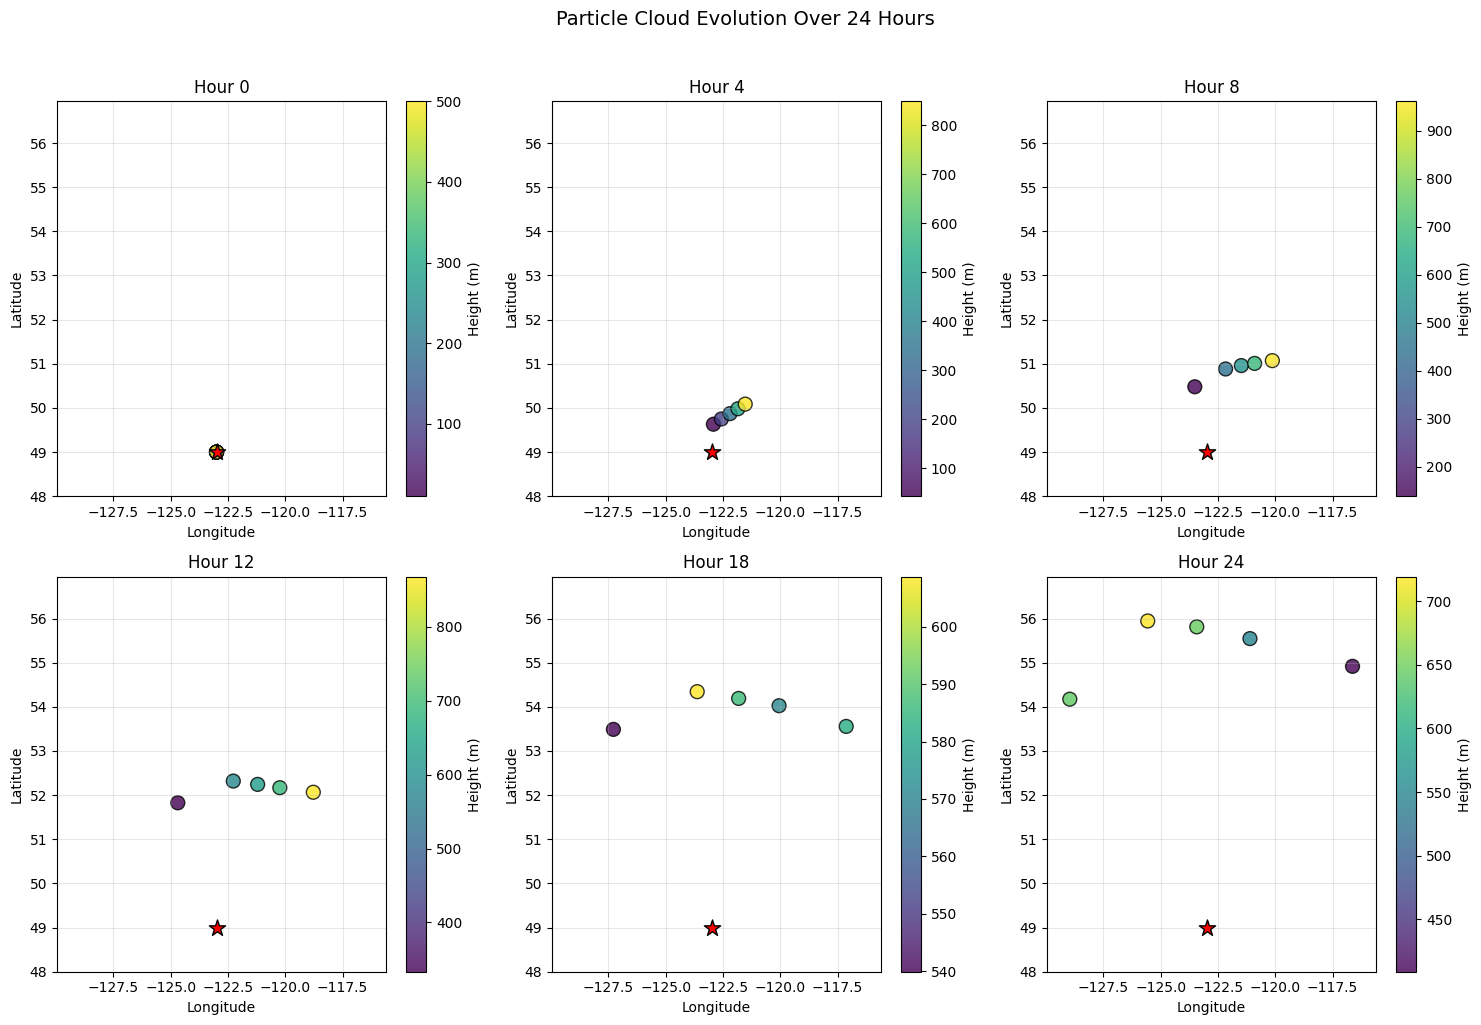

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
hours_to_show = [0, 4, 8, 12, 18, 24]

for idx, hour in enumerate(hours_to_show):
    ax = axes[idx // 3, idx % 3]
    hour_data = traj_dispersion[traj_dispersion['hour_along'] == hour]
    
    if len(hour_data) > 0:
        scatter = ax.scatter(hour_data['lon'], hour_data['lat'], 
                            c=hour_data['height'], cmap='viridis',
                            s=100, alpha=0.8, edgecolors='black')
        plt.colorbar(scatter, ax=ax, label='Height (m)')
    
    ax.scatter(source_lon, source_lat, c='red', s=150, marker='*', 
               zorder=10, edgecolors='black')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Hour {hour}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(traj_dispersion['lon'].min() - 1, traj_dispersion['lon'].max() + 1)
    ax.set_ylim(traj_dispersion['lat'].min() - 1, traj_dispersion['lat'].max() + 1)

plt.suptitle('Particle Cloud Evolution Over 24 Hours', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Continuous Emission Simulation

Simulate a source that continuously emits particles throughout the day. We do this by running trajectories at multiple release times.

In [7]:
# Simulate continuous emission with releases every 3 hours
continuous_emission = hysplit.hysplit_trajectory(
    lat=source_lat,
    lon=source_lon,
    height=50,
    duration=12,
    days=["2012-03-12"],
    daily_hours=[0, 3, 6, 9, 12, 15, 18, 21],
    direction="forward",
    met_type="reanalysis",
    met_dir=str(met_dir),
    exec_dir=str(out_dir)
)

print(f"Continuous emission simulation:")
print(f"  Release times: 8 (every 3 hours)")
print(f"  Total trajectories: {continuous_emission['run'].nunique()}")
print(f"  Total points: {len(continuous_emission)}")

Continuous emission simulation:
  Release times: 8 (every 3 hours)
  Total trajectories: 8
  Total points: 104


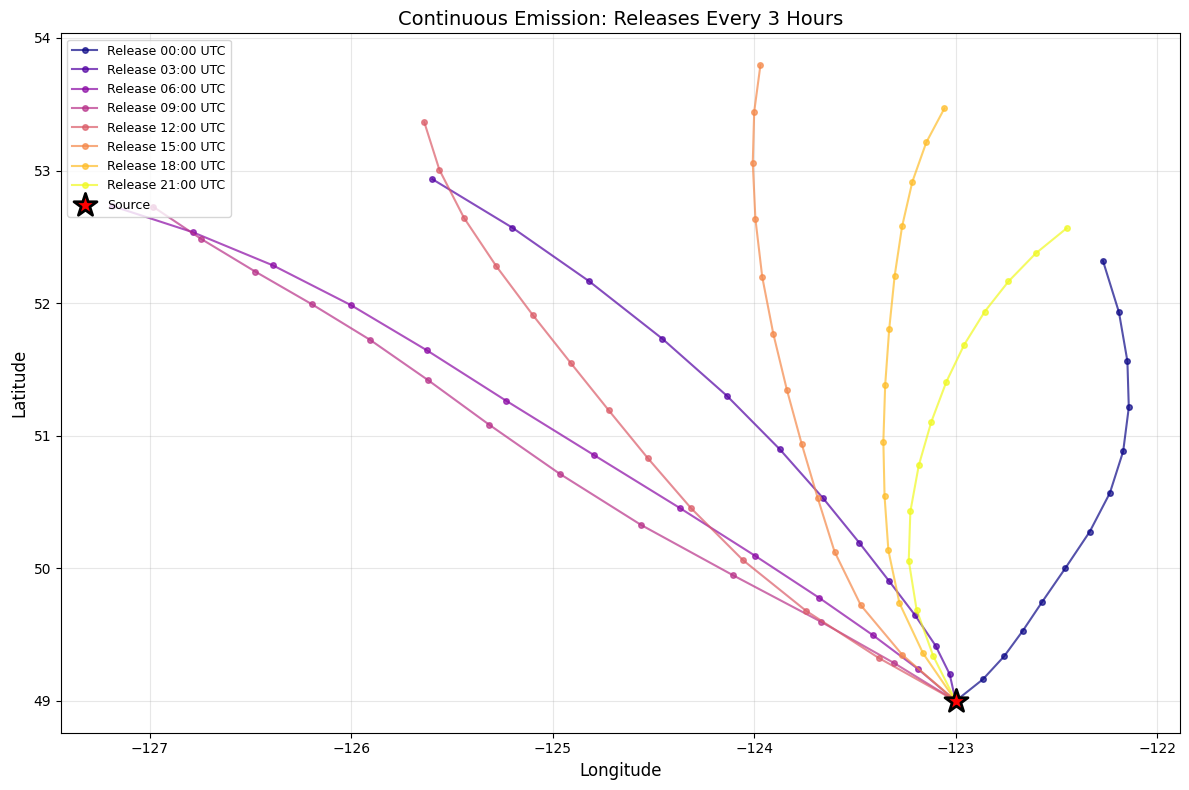

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

n_runs = continuous_emission['run'].nunique()
colors = plt.cm.plasma(np.linspace(0, 1, n_runs))

for i, run_id in enumerate(continuous_emission['run'].unique()):
    run_data = continuous_emission[continuous_emission['run'] == run_id]
    ax.plot(run_data['lon'], run_data['lat'], 'o-',
            color=colors[i], markersize=4, alpha=0.7,
            label=f'Release {i*3:02d}:00 UTC')

ax.scatter(source_lon, source_lat, c='red', s=300, marker='*', 
           zorder=10, label='Source', edgecolors='black', linewidths=2)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Continuous Emission: Releases Every 3 Hours', fontsize=14)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Dispersion Statistics

In [9]:
print("Dispersion Statistics")
print("=" * 50)

final_hour = traj_dispersion['hour_along'].max()
final_positions = traj_dispersion[traj_dispersion['hour_along'] == final_hour]

lat_spread = final_positions['lat'].max() - final_positions['lat'].min()
lon_spread = final_positions['lon'].max() - final_positions['lon'].min()
height_spread = final_positions['height'].max() - final_positions['height'].min()

# Calculate center of mass
center_lat = final_positions['lat'].mean()
center_lon = final_positions['lon'].mean()

print(f"\nAfter {final_hour} hours of transport:")
print(f"  Latitude spread: {lat_spread:.2f}°")
print(f"  Longitude spread: {lon_spread:.2f}°")
print(f"  Vertical spread: {height_spread:.0f} m")
print(f"  Approximate horizontal extent: {((lat_spread**2 + lon_spread**2)**0.5 * 111):.0f} km")
print(f"\nCloud center of mass:")
print(f"  Latitude: {center_lat:.2f}°")
print(f"  Longitude: {center_lon:.2f}°")

Dispersion Statistics

After 24 hours of transport:
  Latitude spread: 1.77°
  Longitude spread: 12.34°
  Vertical spread: 310 m
  Approximate horizontal extent: 1384 km

Cloud center of mass:
  Latitude: 55.28°
  Longitude: -123.14°


## Summary

This notebook demonstrated:

1. **Dispersion Model API** - Using `create_dispersion_model()` with `add_source()` to define particle properties
2. **Trajectory Ensemble** - Simulating dispersion by running multiple trajectories at different heights
3. **Visualization** - Horizontal and vertical dispersion patterns
4. **Time Evolution** - How particle clouds spread over time
5. **Continuous Emission** - Simulating ongoing emissions with multiple release times
6. **Statistics** - Quantifying dispersion extent

The dispersion model is useful for:
- Emergency response (chemical/nuclear releases)
- Air quality modeling
- Volcanic ash transport
- Pollen/spore dispersal studies